
# DATA 304 — Session 2 Demo: Representing Text Numerically

This notebook demonstrates:
- Bag-of-Words (BoW)
- TF-IDF
- N-grams
- Exploring vocabulary and IDF
- **Keyword extraction per document (top-k)**  ← include in demo
- Cosine similarity
- PCA visualization of TF-IDF
- Saving sparse matrices


In [1]:
import os
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from scipy import sparse

import matplotlib.pyplot as plt

docs = [
    "Data wrangling with Python for messy data",
    "Python handles analysis of messy data and supports data analysis",
    "Wrangling text data requires cleaning and tokenization",
    "Machine learning uses numeric features like TF IDF",
    "Clustering documents with cosine similarity requires vectors"
]

print(f"#documents: {len(docs)}")

#documents: 5


## Bag-of-Words (BoW)

In [2]:
bow = CountVectorizer()
X_bow = bow.fit_transform(docs)

bow_df = pd.DataFrame(X_bow.toarray(), columns=bow.get_feature_names_out())
bow_df

,analysis,and,cleaning,clustering,cosine,data,documents,features,for,handles,...,requires,similarity,supports,text,tf,tokenization,uses,vectors,with,wrangling
0,0,0,0,0,0,2,0,0,1,0,...,0,0,0,0,0,0,0,0,1,1
1,2,1,0,0,0,2,0,0,0,1,...,0,0,1,0,0,0,0,0,0,0
2,0,1,1,0,0,1,0,0,0,0,...,1,0,0,1,0,1,0,0,0,1
3,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,1,0,1,0,0,0
4,0,0,0,1,1,0,1,0,0,0,...,1,1,0,0,0,0,0,1,1,0


## TF-IDF (with English stopwords)

In [3]:
tfidf = TfidfVectorizer(stop_words='english')
X_tfidf = tfidf.fit_transform(docs)

tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out()).round(3)
tfidf_df

,analysis,cleaning,clustering,cosine,data,documents,features,handles,idf,learning,...,python,requires,similarity,supports,text,tf,tokenization,uses,vectors,wrangling
0,0.000,0.000,0.000,0.000,0.692,0.000,0.000,0.000,0.000,0.000,...,0.417,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.417
1,0.663,0.000,0.000,0.000,0.444,0.000,0.000,0.332,0.000,0.000,...,0.268,0.000,0.000,0.332,0.000,0.000,0.000,0.000,0.000,0.000
2,0.000,0.459,0.000,0.000,0.307,0.000,0.000,0.000,0.000,0.000,...,0.000,0.370,0.000,0.000,0.459,0.000,0.459,0.000,0.000,0.370
3,0.000,0.000,0.000,0.000,0.000,0.000,0.354,0.000,0.354,0.354,...,0.000,0.000,0.000,0.000,0.000,0.354,0.000,0.354,0.000,0.000
4,0.000,0.000,0.421,0.421,0.000,0.421,0.000,0.000,0.000,0.000,...,0.000,0.339,0.421,0.000,0.000,0.000,0.000,0.000,0.421,0.000


## Stopwords

In [4]:
# 1) Built-in English
tfidf_default = TfidfVectorizer(stop_words='english')
X_default = tfidf_default.fit_transform(docs)

# 2) Simple custom list
simple_stops = ['data', 'python', 'and']
tfidf_simple = TfidfVectorizer(stop_words=simple_stops)
X_simple = tfidf_simple.fit_transform(docs)

# 3) Customized English: add + remove, then convert to LIST
extra_words = {'data', 'python'}        # add
kept_words  = {'against', 'under'}      # keep (remove from stop list)
custom_stops_set = (ENGLISH_STOP_WORDS.union(extra_words)).difference(kept_words)
custom_stops = list(custom_stops_set)

tfidf_custom = TfidfVectorizer(stop_words=custom_stops)
X_custom = tfidf_custom.fit_transform(docs)

print("Default English:", len(tfidf_default.get_feature_names_out()), "terms")
print("Simple custom:", len(tfidf_simple.get_feature_names_out()), "terms")
print("Customized English:", len(tfidf_custom.get_feature_names_out()), "terms")
print("Added words:", extra_words)
print("Kept words:", kept_words)

Default English: 24 terms
Simple custom: 25 terms
Customized English: 22 terms
Added words: {'data', 'python'}
Kept words: {'against', 'under'}


## N-grams: unigrams + bigrams

In [5]:
tfidf_uni_bi = TfidfVectorizer(stop_words='english', ngram_range=(1,2))
X_uni_bi = tfidf_uni_bi.fit_transform(docs)

# Show a sample of features to keep output readable
features = tfidf_uni_bi.get_feature_names_out()
pd.DataFrame({'feature': features}).head(20)

,feature
0,analysis
1,analysis messy
2,cleaning
3,cleaning tokenization
4,clustering
5,clustering documents
6,cosine
7,cosine similarity
8,data
9,data analysis


## Exploring vocabulary importance (IDF)

In [6]:
idf = tfidf.idf_
vocab = tfidf.get_feature_names_out()
idf_df = pd.DataFrame({'term': vocab, 'idf': idf}).sort_values('idf', ascending=False)
idf_df.head(20)

,term,idf
0,analysis,2.098612
1,cleaning,2.098612
2,clustering,2.098612
3,cosine,2.098612
5,documents,2.098612
6,features,2.098612
7,handles,2.098612
8,idf,2.098612
20,tokenization,2.098612
9,learning,2.098612


## Keyword extraction per document (top-k by TF-IDF)

In [7]:
k = 5
feature_array = np.array(tfidf.get_feature_names_out())
tfidf_matrix = X_tfidf.toarray()

for i, row in enumerate(tfidf_matrix, start=1):
    top_idx = row.argsort()[-k:][::-1]
    top_terms = feature_array[top_idx]
    top_scores = row[top_idx]
    print(f"Doc {i}:", list(zip(top_terms, np.round(top_scores, 3))))

Doc 1: [('data', np.float64(0.692)), ('wrangling', np.float64(0.417)), ('python', np.float64(0.417)), ('messy', np.float64(0.417)), ('tf', np.float64(0.0))]
Doc 2: [('analysis', np.float64(0.663)), ('data', np.float64(0.444)), ('supports', np.float64(0.332)), ('handles', np.float64(0.332)), ('python', np.float64(0.268))]
Doc 3: [('tokenization', np.float64(0.459)), ('text', np.float64(0.459)), ('cleaning', np.float64(0.459)), ('wrangling', np.float64(0.37)), ('requires', np.float64(0.37))]
Doc 4: [('uses', np.float64(0.354)), ('tf', np.float64(0.354)), ('features', np.float64(0.354)), ('idf', np.float64(0.354)), ('machine', np.float64(0.354))]
Doc 5: [('vectors', np.float64(0.421)), ('similarity', np.float64(0.421)), ('clustering', np.float64(0.421)), ('cosine', np.float64(0.421)), ('documents', np.float64(0.421))]


## Cosine similarity of documents (using TF-IDF)

In [8]:
sim = cosine_similarity(X_tfidf)
sim_df = pd.DataFrame(sim, index=[f"Doc{i}" for i in range(1, len(docs)+1)],
                           columns=[f"Doc{i}" for i in range(1, len(docs)+1)]).round(3)
sim_df

,Doc1,Doc2,Doc3,Doc4,Doc5
Doc1,1.000,0.530,0.367,0.0,0.000
Doc2,0.530,1.000,0.136,0.0,0.000
Doc3,0.367,0.136,1.000,0.0,0.126
Doc4,0.000,0.000,0.000,1.0,0.000
Doc5,0.000,0.000,0.126,0.0,1.000


## PCA visualization of TF-IDF

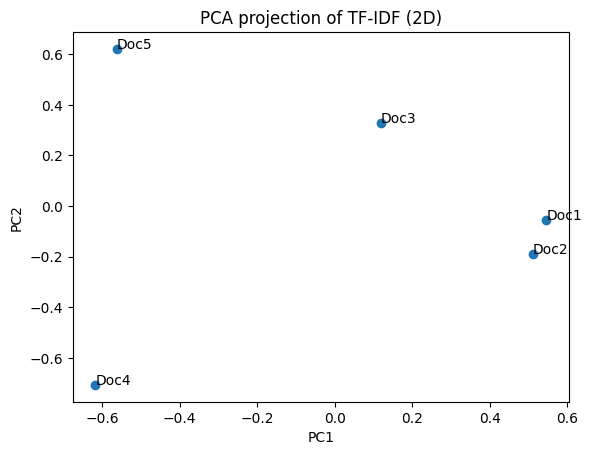

In [9]:
coords = PCA(n_components=2).fit_transform(X_tfidf.toarray())
plt.figure()
plt.scatter(coords[:, 0], coords[:, 1])
for i, (x, y) in enumerate(coords, start=1):
    plt.text(x, y, f"Doc{i}")
plt.title("PCA projection of TF-IDF (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## Saving sparse TF-IDF to disk (.npz)

In [10]:
# --- Temporary scaling to illustrate memory effect ---
# Duplicate the corpus so the TF-IDF matrix becomes larger
docs_large = docs * 500

# Recompute TF-IDF on the larger corpus
tfidf_large = TfidfVectorizer(stop_words="english", max_features=5000)
X_large = tfidf_large.fit_transform(docs_large)

# Show the matrix type
print("Matrix type:", type(X_large))
print("Matrix shape:", X_large.shape)

# --- Save dense vs. sparse representations ---
np.save("./data/tfidf_dense.npy", X_large.toarray())   # dense NumPy array
np.save("./data/tfidf_object.npy", X_large)            # pickled sparse object
sparse.save_npz("./data/tfidf_sparse.npz", X_large)    # optimized sparse format

# --- Compare approximate memory usage in RAM ---
dense_kb = (X_large.toarray().nbytes) / 1024
sparse_kb = (X_large.data.nbytes + X_large.indices.nbytes + X_large.indptr.nbytes) / 1024

print("\nRAM")
print(f"Dense RAM usage:  {dense_kb:.1f} KB")
print(f"Sparse RAM usage: {sparse_kb:.1f} KB")

# --- Compare file sizes on disk ---
dense_kb = os.path.getsize("./data/tfidf_dense.npy") / 1024
object_kb = os.path.getsize("./data/tfidf_object.npy") / 1024
sparse_kb = os.path.getsize("./data/tfidf_sparse.npz") / 1024

print("\nOn Disk")
print(f"Dense file:  {dense_kb:.1f} KB")
print(f"Object file: {object_kb:.1f} KB")
print(f"Sparse file: {sparse_kb:.1f} KB")

Matrix type: <class 'scipy.sparse._csr.csr_matrix'>
Matrix shape: (2500, 24)

RAM
Dense RAM usage:  468.8 KB
Sparse RAM usage: 185.6 KB

On Disk
Dense file:  468.9 KB
Object file: 186.1 KB
Sparse file: 5.1 KB
